In [1]:
import pandas as pd
import numpy as np

# ==========================
# LOAD DATA
# ==========================
df = pd.read_csv("C:\\Users\\santh\\output_candles_silver_01.csv")

df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ==========================
# BASIC CALCULATIONS
# ==========================
close = df['Close']
open_ = df['Open']
high = df['High']
low = df['Low']
volume = df['Volume']

In [2]:
# ==========================
# 1️⃣ EMA (20)
# ==========================
df['EMA'] = close.ewm(span=20, adjust=False).mean()

# ==========================
# 2️⃣ Aroon Oscillator (14)
# ==========================
period = 14

aroon_up = high.rolling(period+1).apply(
    lambda x: np.argmax(x) / period * 100, raw=True
)
aroon_down = low.rolling(period+1).apply(
    lambda x: np.argmin(x) / period * 100, raw=True
)

df['AroonOscillator'] = aroon_up - aroon_down

# ==========================
# 3️⃣ SAR (Basic Non-TALIB)
# ==========================
df['SAR'] = low.shift(1)

# ==========================
# 4️⃣ RSI (14)
# ==========================
delta = close.diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

# ==========================
# 5️⃣ Qstick (10)
# ==========================
df['Qstick'] = (close - open_).rolling(10).mean()

# ==========================
# 6️⃣ OBV
# ==========================
df['OBV'] = (np.sign(close.diff()) * volume).fillna(0).cumsum()
# ==========================
# 7️⃣ Bull / Bear Power
# ==========================
ema_13 = close.ewm(span=13, adjust=False).mean()
df['Bull_Power'] = high - ema_13
df['Bear_Power'] = low - ema_13

# ==========================
# 8️⃣ Bollinger Bands (20,2)
# ==========================
ma20 = close.rolling(20).mean()
std20 = close.rolling(20).std()

df['BB_mid'] = ma20
df['BB_up'] = ma20 + 2 * std20
df['BB_down'] = ma20 - 2 * std20

# ==========================
# 9️⃣ ATR (14)
# ==========================
hl = high - low
hc = np.abs(high - close.shift())
lc = np.abs(low - close.shift())

tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
df['ATR_keltner'] = tr.rolling(14).mean()

# ==========================
# 🔟 Keltner Channel
# ==========================
df['Keltner_mid'] = close.ewm(span=20, adjust=False).mean()
df['Keltner_up'] = df['Keltner_mid'] + 2 * df['ATR_keltner']
df['Keltner_down'] = df['Keltner_mid'] - 2 * df['ATR_keltner']

# ==========================
# ZERO FILL INITIAL ROWS
# ==========================
df = df.fillna(0)

# ==========================
# SAVE FILE
# ==========================
df.to_csv("silver_TTR_ratios.csv", index=False)



2.20.0
Starting silver price prediction with GRU model...
(1321, 25)
Data loaded successfully. Shape: (1321, 25)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Hammer', 'Engulfing.bullish_engulfing', 'Engulfing.bearish_engulfing', 'Inverted_Hammer', 'Shooting_Star', 'EMA', 'AroonOscillator', 'SAR', 'RSI', 'Qstick', 'OBV', 'Bull_Power', 'Bear_Power', 'BB_mid', 'BB_up', 'BB_down', 'ATR_keltner', 'Keltner_mid', 'Keltner_up', 'Keltner_down']
Using 25 numeric features
Created 1261 sequences with shape (1261, 60, 25)
Train set: (1008, 60, 25), Test set: (253, 60, 25)


C:\Users\santh\.ipython\ana\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
C:\Users\santh\.ipython\ana\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 60, 50)         │        11,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,901 (105.08 KB)

 Trainable params: 26,901 (105.08 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 0.0414 - val_loss: 0.0063
Epoch 2/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0072 - val_loss: 0.0029
Epoch 3/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0046 - val_loss: 0.0026
Epoch 4/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0039 - val_loss: 0.0024
Epoch 5/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0033 - val_loss: 0.0015
Epoch 6/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0027 - val_loss: 0.0014
Epoch 7/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 8/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0022 - val_loss: 0.0013
Epoch 9/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0022 - val_loss: 0.0012
Epoch 10/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0020 - val_loss: 0.0012
Epoch 11/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 12/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss

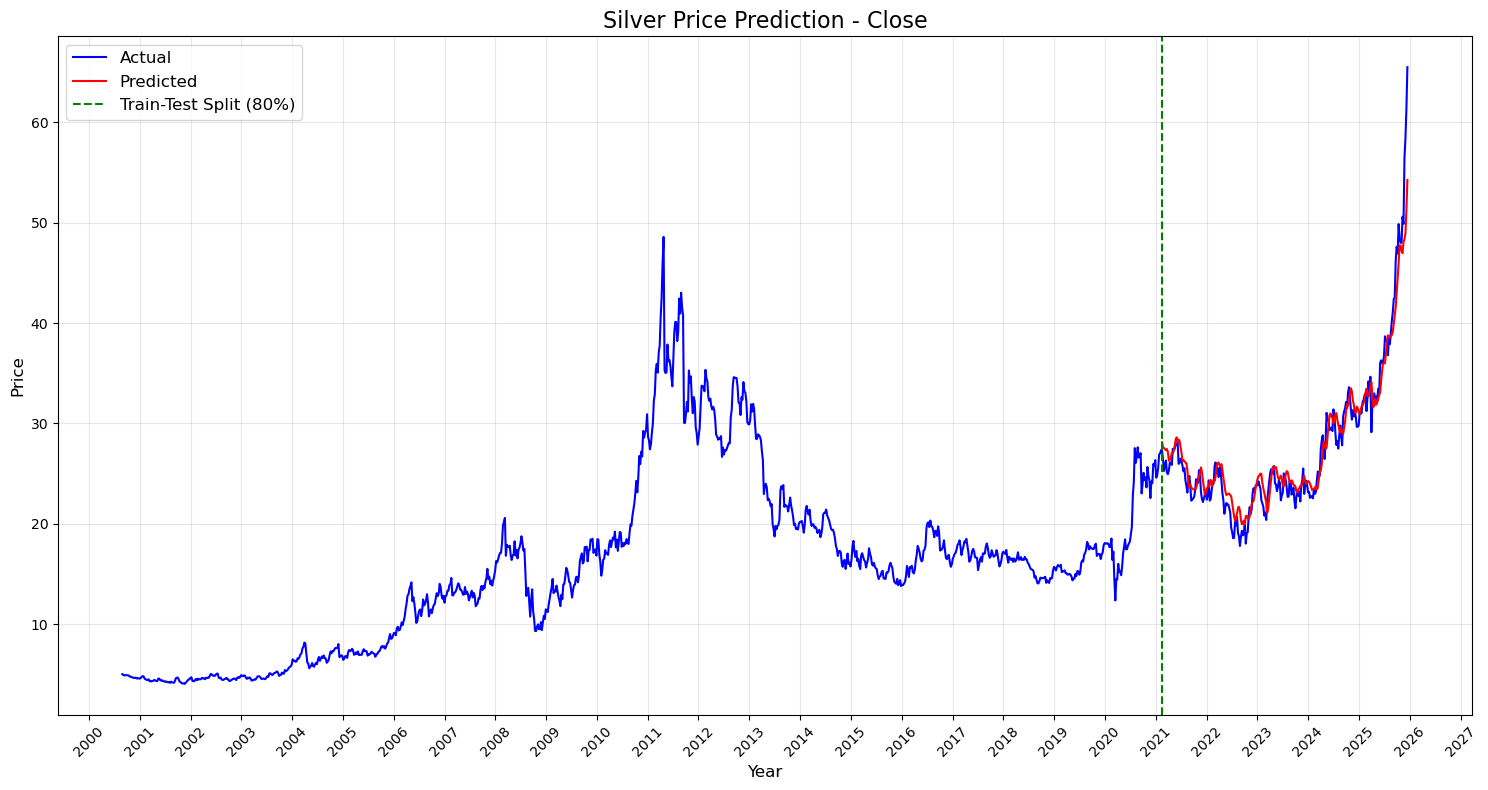

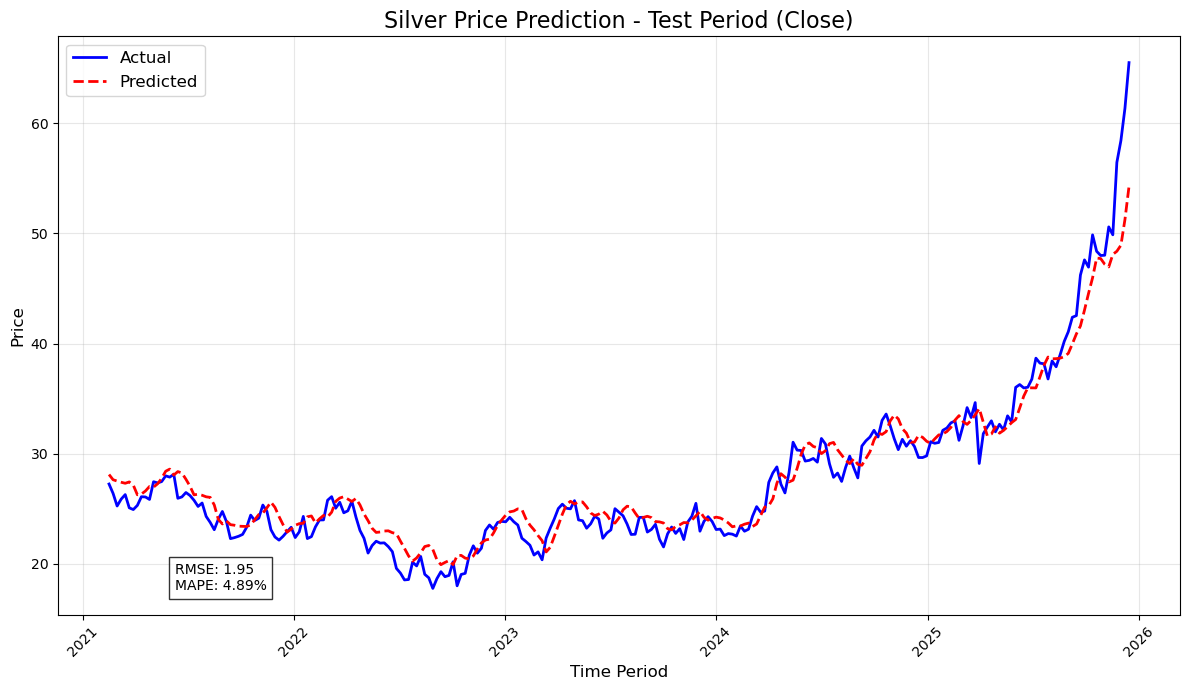


Model Performance Metrics:
Mean Squared Error: 3.8162
Root Mean Squared Error: 1.9535
Mean Absolute Error: 1.3534
R² Score: 0.9345
Mean Absolute Percentage Error: 4.89%


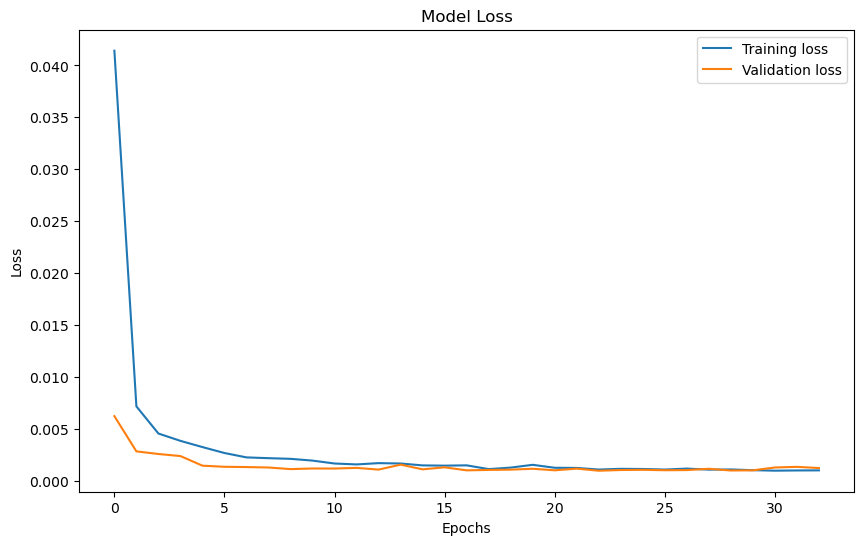

In [9]:

#GRU
# Installation of required packages
# Run these commands in your terminal or command prompt before running the code
"""
#pip install numpy pandas matplotlib scikit-learn tensorflow
"""
import tensorflow as tf
print(tf.__version__)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import os

# Set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# Load your data
def load_data(filepath):
    df = pd.read_csv(filepath)
    # Convert the first column to datetime if it's a date
    df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0])
    df.set_index(df.columns[0], inplace=True)
    print(df.shape)
    print(f"Data loaded successfully. Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    return df

# Function to prepare data for GRU model with 80-20 split
def prepare_data(df, target_col='Close', sequence_length=60):
    # Ensure all data is numeric
    numeric_df = df.select_dtypes(include=[np.number])
    print(f"Using {numeric_df.shape[1]} numeric features")
    
    # Create target scaler (for inverting predictions later)
    target_scaler = MinMaxScaler(feature_range=(0, 1))
    target_scaler.fit(df[[target_col]].values)
    
    # Scale all features
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(numeric_df)
    
    # Create sequences
    X, y = [], []
    for i in range(len(scaled_data) - sequence_length):
        X.append(scaled_data[i:i + sequence_length])
        # Get the target column index
        target_idx = list(numeric_df.columns).index(target_col)
        y.append(scaled_data[i + sequence_length, target_idx])
    
    X, y = np.array(X), np.array(y)
    print(f"Created {len(X)} sequences with shape {X.shape}")
    
    # Calculate the split point at 80%
    train_size = int(len(X) * 0.8)
    
    # Split data into train and test sets
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
    
    return X_train, X_test, y_train, y_test, scaler, target_scaler, numeric_df, train_size

# Function to build and train the GRU model
def build_gru_model(X_train, y_train, X_test, y_test, epochs=100, batch_size=32):
    # Get input dimensions
    n_timesteps, n_features = X_train.shape[1], X_train.shape[2]
    
    # Build model
    model = Sequential()
    model.add(GRU(units=50, return_sequences=True, input_shape=(n_timesteps, n_features)))
    model.add(Dropout(0.2))
    model.add(GRU(units=50, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))
    
    # Compile model
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    print(model.summary())
    
    # Set up early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=1
    )
    
    return model, history

# Function to make predictions
def make_predictions(model, X_test, target_scaler, y_test, numeric_df, target_col):
    # Make predictions
    print("Making predictions...")
    y_pred = model.predict(X_test)
    
    # Get original scale target values
    # First, create a container for the scaled values
    y_test_container = np.zeros((len(y_test), len(numeric_df.columns)))
    y_pred_container = np.zeros((len(y_pred), len(numeric_df.columns)))
    
    # Put the scaled values in the right column
    target_idx = list(numeric_df.columns).index(target_col)
    y_test_container[:, target_idx] = y_test
    y_pred_container[:, target_idx] = y_pred.flatten()
    
    # Transform back to original scale
    y_test_actual = target_scaler.inverse_transform(y_test_container)[:, target_idx]
    y_pred_actual = target_scaler.inverse_transform(y_pred_container)[:, target_idx]
    
    return y_test_actual, y_pred_actual

# Improved plotting function with years on x-axis
def plot_with_years(df, y_test_actual, y_pred_actual, target_col, sequence_length, train_size):
    """
    Creates a time series plot with years on x-axis, showing actual values for the entire dataset
    and predicted values for only the test portion (last 20%).
    """
    # Get the entire actual data
    actual_full = df[target_col].values
    
    # Create a dataframe with the full data
    result_df = pd.DataFrame(index=df.index)
    result_df['Actual'] = actual_full
    
    # Calculate the dates for the test data
    # We need to account for sequence_length and train_size
    test_start_idx = train_size + sequence_length
    test_dates = df.index[test_start_idx:]
    
    # Add predicted values only for the test portion
    result_df['Predicted'] = np.nan  # Initialize with NaN
    
    # Make sure we have enough test dates for our predictions
    if len(test_dates) >= len(y_pred_actual):
        result_df.loc[test_dates[:len(y_pred_actual)], 'Predicted'] = y_pred_actual
    else:
        print(f"Warning: Not enough test dates ({len(test_dates)}) for predictions ({len(y_pred_actual)})")
        # Use as many as we can
        result_df.loc[test_dates, 'Predicted'] = y_pred_actual[:len(test_dates)]
    
    # Create the plot
    plt.figure(figsize=(15, 8))
    
    # Plot full actual data
    plt.plot(result_df.index, result_df['Actual'], color='blue', label='Actual')
    
    # Plot predictions for test portion only
    plt.plot(result_df.index, result_df['Predicted'], color='red', label='Predicted')
    
    # Add vertical line at the train/test split
    split_date = df.index[test_start_idx]
    plt.axvline(x=split_date, color='green', linestyle='--', 
                label=f'Train-Test Split (80%)')
    
    # Format x-axis to show years
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    
    # Add labels and title
    plt.title(f'Silver Price Prediction - {target_col}', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Price', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the figure
    plt.savefig('Silver_price_prediction_with_years.png', dpi=300)
    
    # Show the plot
    plt.show()
    
    return result_df

# Function to plot only test period predictions
def plot_test_predictions(df, y_test_actual, y_pred_actual, sequence_length, train_size, target_col='Close'):
    """
    Creates a plot showing only the test period with actual vs predicted values.
    
    Parameters:
    df (DataFrame): Original dataframe with datetime index
    y_test_actual (array): Actual values from test set
    y_pred_actual (array): Predicted values from model
    sequence_length (int): Number of timesteps used in each sequence
    train_size (int): Number of sequences in training set
    target_col (str): Name of target column being predicted
    
    Returns:
    DataFrame: DataFrame containing actual and predicted values
    """
    # Calculate the correct start index for test predictions
    test_start_idx = train_size + sequence_length
    
    # Get only the test period dates
    test_dates = df.index[test_start_idx:test_start_idx + len(y_pred_actual)]
    
    # Create a dataframe for the test period only
    test_df = pd.DataFrame(index=test_dates)
    test_df['Actual'] = y_test_actual[:len(test_dates)]
    test_df['Predicted'] = y_pred_actual[:len(test_dates)]
    
    # Create the plot
    plt.figure(figsize=(12, 7))
    
    # Plot data
    plt.plot(test_df.index, test_df['Actual'], 'b-', linewidth=2, label='Actual')
    plt.plot(test_df.index, test_df['Predicted'], 'r--', linewidth=2, label='Predicted')
    
    # Format x-axis based on the date range
    date_range = (test_df.index[-1] - test_df.index[0]).days
    
    if date_range > 365*2:  # More than 2 years
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    elif date_range > 90:  # More than 3 months
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    else:  # Less than 3 months
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
        plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    
    # Add labels and title
    plt.title(f'Silver Price Prediction - Test Period ({target_col})', fontsize=16)
    plt.xlabel('Time Period', fontsize=12)
    plt.ylabel('Price', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Calculate and display error metrics on the plot
    mse = np.mean((test_df['Actual'] - test_df['Predicted'])**2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((test_df['Actual'] - test_df['Predicted']) / test_df['Actual'])) * 100
    
    plt.figtext(0.15, 0.15, f'RMSE: {rmse:.2f}\nMAPE: {mape:.2f}%', 
                bbox=dict(facecolor='white', alpha=0.8), fontsize=10)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the figure
    plt.savefig('Silver_price_test_predictions.png', dpi=300)
    
    # Show the plot
    plt.show()
    
    return test_df

# Function to evaluate model
def evaluate_model(y_test_actual, y_pred_actual):
    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    r2 = r2_score(y_test_actual, y_pred_actual)
    
    print("\nModel Performance Metrics:")
    print(f'Mean Squared Error: {mse:.4f}')
    print(f'Root Mean Squared Error: {rmse:.4f}')
    print(f'Mean Absolute Error: {mae:.4f}')
    print(f'R² Score: {r2:.4f}')
    
    # Calculate percentage error
    mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100
    print(f'Mean Absolute Percentage Error: {mape:.2f}%')

# Main function
def main(filepath, target_col='Close', sequence_length=60, epochs=100, batch_size=32):
    print(f"Starting silver price prediction with GRU model...")
    
    # Load data
    df = load_data(filepath)
    
    # Prepare data with 80-20 split
    X_train, X_test, y_train, y_test, scaler, target_scaler, numeric_df, train_size = prepare_data(
        df, target_col, sequence_length
    )
    
    # Build and train model
    model, history = build_gru_model(X_train, y_train, X_test, y_test, epochs, batch_size)
    
    # Make predictions
    y_test_actual, y_pred_actual = make_predictions(model, X_test, target_scaler, y_test, numeric_df, target_col)
    
    # Plot both visualizations
    # 1. Full dataset with train/test split
    result_df = plot_with_years(df, y_test_actual, y_pred_actual, target_col, sequence_length, train_size)
    
    # 2. Test period only with metrics
    test_df = plot_test_predictions(df, y_test_actual, y_pred_actual, sequence_length, train_size, target_col)
    
    # Evaluate model
    evaluate_model(y_test_actual, y_pred_actual)
    
    # Plot training history
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training loss')
    plt.plot(history.history['val_loss'], label='Validation loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig('training_history.png')
    plt.show()
    
    return model, history, y_test_actual, y_pred_actual, result_df, test_df

# Example usage
if __name__ == "__main__":
    # Replace with your actual file path
    filepath = "C:\\Users\\santh\\silver_TTR_ratios.csv"
    target_col = "Close"  # Column to predict
    
    # Run the pipeline
    model, history, y_test_actual, y_pred_actual, result_df,test_df = main(
        filepath=filepath,
        target_col=target_col,
        sequence_length=60,  # Number of time steps to use as input
        epochs=60,
        batch_size=32
    )


2.20.0
Starting Silver Price Prediction with ANN...
(1321, 25)
Data loaded successfully. Shape: (1321, 25)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Hammer', 'Engulfing.bullish_engulfing', 'Engulfing.bearish_engulfing', 'Inverted_Hammer', 'Shooting_Star', 'EMA', 'AroonOscillator', 'SAR', 'RSI', 'Qstick', 'OBV', 'Bull_Power', 'Bear_Power', 'BB_mid', 'BB_up', 'BB_down', 'ATR_keltner', 'Keltner_mid', 'Keltner_up', 'Keltner_down']
Using 25 numeric features
Created 1261 sequences with shape (1261, 60, 25)
Train set: (1008, 60, 25), Test set: (253, 60, 25)
ANN Train shape: (1008, 1500)
ANN Test shape: (253, 1500)


C:\Users\santh\.ipython\ana\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
C:\Users\santh\.ipython\ana\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 128)            │       192,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,449 (783.00 KB)

 Trainable params: 200,449 (783.00 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0976 - val_loss: 0.0419
Epoch 2/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0161 - val_loss: 0.0271
Epoch 3/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0099 - val_loss: 0.0234
Epoch 4/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0074 - val_loss: 0.0147
Epoch 5/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0065 - val_loss: 0.0063
Epoch 6/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0060 - val_loss: 0.0099
Epoch 7/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0066 - val_loss: 0.0052
Epoch 8/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0067 - val_loss: 0.0138
Epoch 9/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0055 - val_loss: 0.0118
Epoch 10/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0049 - val_loss: 0.0054
Epoch 11/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0046 - val_loss: 0.0131
Epoch 12/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0049 - 

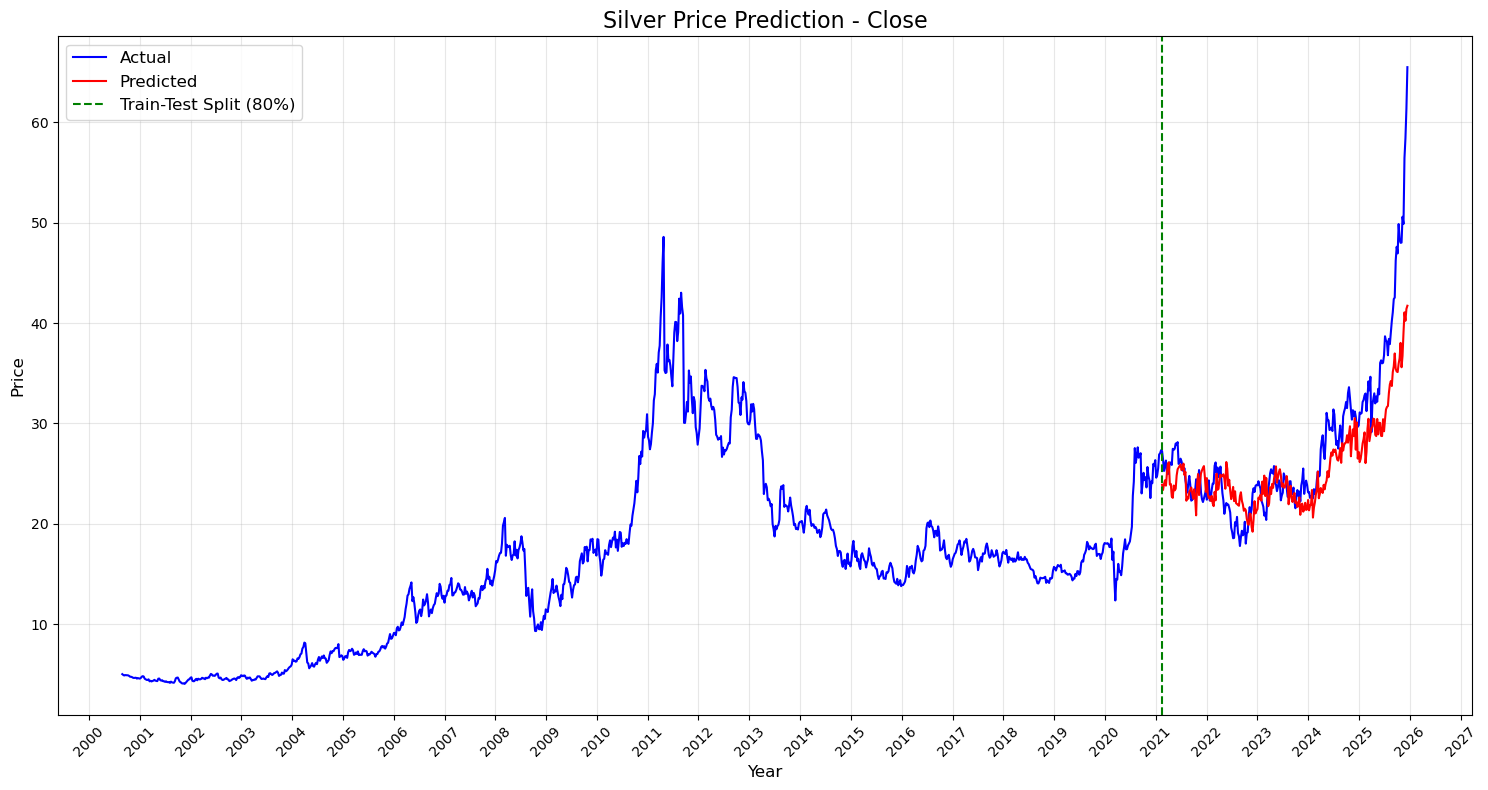

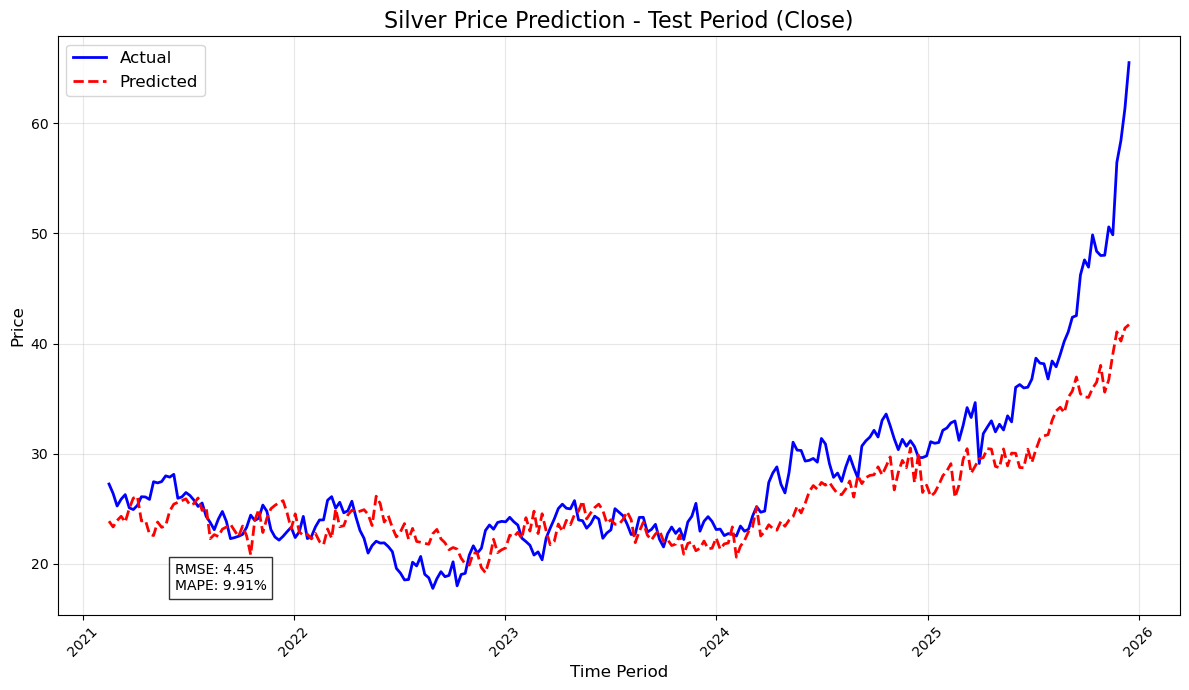


Model Performance Metrics:
Mean Squared Error: 19.8261
Root Mean Squared Error: 4.4526
Mean Absolute Error: 3.0446
R² Score: 0.6596
Mean Absolute Percentage Error: 9.91%


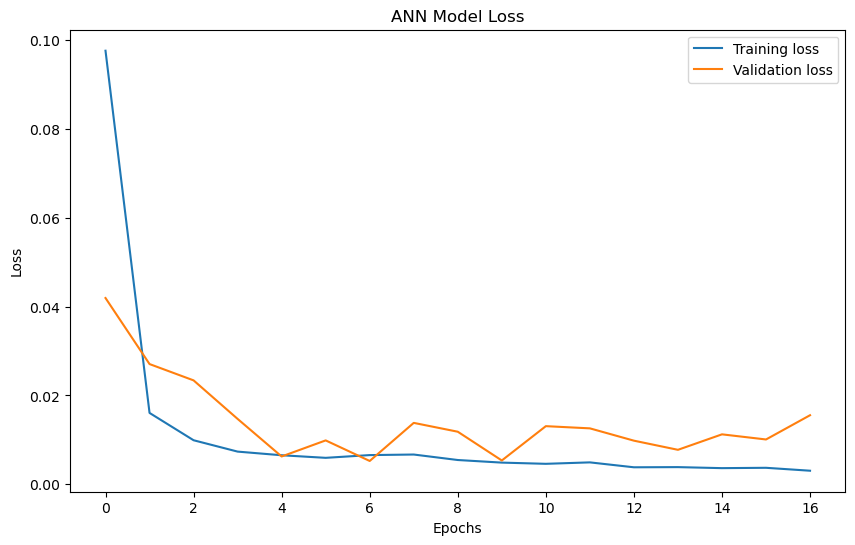

In [22]:
# ANN for Silver Price Prediction
# Installation of required packages
# Run these commands in your terminal or command prompt before running the code
"""
# pip install numpy pandas matplotlib scikit-learn tensorflow
"""

import tensorflow as tf
print(tf.__version__)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import os

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# -------------------------------
# Load CSV Data
# -------------------------------
def load_data(filepath):
    df = pd.read_csv(filepath)
    df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0])  # Convert first column to datetime
    df.set_index(df.columns[0], inplace=True)
    print(df.shape)
    print(f"Data loaded successfully. Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    return df

# -------------------------------
# Prepare Data for ANN
# -------------------------------
def prepare_data(df, target_col='Close', sequence_length=60):
    numeric_df = df.select_dtypes(include=[np.number])
    print(f"Using {numeric_df.shape[1]} numeric features")
    
    # Target scaler for inverse transform
    target_scaler = MinMaxScaler(feature_range=(0,1))
    target_scaler.fit(df[[target_col]].values)
    
    # Scale all features
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(numeric_df)
    
    # Create sequences
    X, y = [], []
    for i in range(len(scaled_data) - sequence_length):
        X.append(scaled_data[i:i+sequence_length])
        target_idx = list(numeric_df.columns).index(target_col)
        y.append(scaled_data[i + sequence_length, target_idx])
    
    X, y = np.array(X), np.array(y)
    print(f"Created {len(X)} sequences with shape {X.shape}")
    
    # Split 80-20
    train_size = int(len(X)*0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
    
    return X_train, X_test, y_train, y_test, scaler, target_scaler, numeric_df, train_size

# -------------------------------
# Build ANN Model
# -------------------------------
def build_ann_model(X_train, y_train, X_test, y_test, epochs=100, batch_size=32):
    n_features = X_train.shape[1]
    
    model = Sequential()
    model.add(Dense(128, activation='relu', input_dim=n_features))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1))  # Output
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    print(model.summary())
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=1
    )
    
    return model, history

# -------------------------------
# Make Predictions
# -------------------------------
def make_predictions(model, X_test, target_scaler, y_test, numeric_df, target_col):
    y_pred = model.predict(X_test)
    
    # Inverse transform
    y_test_container = np.zeros((len(y_test), len(numeric_df.columns)))
    y_pred_container = np.zeros((len(y_pred), len(numeric_df.columns)))
    target_idx = list(numeric_df.columns).index(target_col)
    
    y_test_container[:, target_idx] = y_test
    y_pred_container[:, target_idx] = y_pred.flatten()
    
    y_test_actual = target_scaler.inverse_transform(y_test_container)[:, target_idx]
    y_pred_actual = target_scaler.inverse_transform(y_pred_container)[:, target_idx]
    
    return y_test_actual, y_pred_actual

# -------------------------------
# Plot Full Dataset with Years
# -------------------------------
def plot_with_years(df, y_test_actual, y_pred_actual, target_col, sequence_length, train_size):
    actual_full = df[target_col].values
    result_df = pd.DataFrame(index=df.index)
    result_df['Actual'] = actual_full
    
    test_start_idx = train_size + sequence_length
    test_dates = df.index[test_start_idx:]
    
    result_df['Predicted'] = np.nan
    if len(test_dates) >= len(y_pred_actual):
        result_df.loc[test_dates[:len(y_pred_actual)], 'Predicted'] = y_pred_actual
    else:
        result_df.loc[test_dates, 'Predicted'] = y_pred_actual[:len(test_dates)]
    
    plt.figure(figsize=(15,8))
    plt.plot(result_df.index, result_df['Actual'], color='blue', label='Actual')
    plt.plot(result_df.index, result_df['Predicted'], color='red', label='Predicted')
    plt.axvline(df.index[test_start_idx], color='green', linestyle='--', label='Train-Test Split (80%)')
    
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.title(f'Silver Price Prediction - {target_col}', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Price', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('Silver_price_prediction_with_years.png', dpi=300)
    plt.show()
    
    return result_df

# -------------------------------
# Plot Test Period
# -------------------------------
def plot_test_predictions(df, y_test_actual, y_pred_actual, sequence_length, train_size, target_col='Close'):
    test_start_idx = train_size + sequence_length
    test_dates = df.index[test_start_idx:test_start_idx + len(y_pred_actual)]
    
    test_df = pd.DataFrame(index=test_dates)
    test_df['Actual'] = y_test_actual[:len(test_dates)]
    test_df['Predicted'] = y_pred_actual[:len(test_dates)]
    
    plt.figure(figsize=(12,7))
    plt.plot(test_df.index, test_df['Actual'], 'b-', linewidth=2, label='Actual')
    plt.plot(test_df.index, test_df['Predicted'], 'r--', linewidth=2, label='Predicted')
    
    date_range = (test_df.index[-1] - test_df.index[0]).days
    if date_range > 365*2:
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    elif date_range > 90:
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    else:
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
        plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    
    plt.title(f'Silver Price Prediction - Test Period ({target_col})', fontsize=16)
    plt.xlabel('Time Period', fontsize=12)
    plt.ylabel('Price', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    mse = np.mean((test_df['Actual'] - test_df['Predicted'])**2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((test_df['Actual'] - test_df['Predicted']) / test_df['Actual'])) * 100
    plt.figtext(0.15, 0.15, f'RMSE: {rmse:.2f}\nMAPE: {mape:.2f}%', bbox=dict(facecolor='white', alpha=0.8), fontsize=10)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('Silver_price_test_predictions.png', dpi=300)
    plt.show()
    
    return test_df

# -------------------------------
# Function to evaluate model
# -------------------------------
def evaluate_model(y_test_actual, y_pred_actual):
    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    r2 = r2_score(y_test_actual, y_pred_actual)
    
    print("\nModel Performance Metrics:")
    print(f'Mean Squared Error: {mse:.4f}')
    print(f'Root Mean Squared Error: {rmse:.4f}')
    print(f'Mean Absolute Error: {mae:.4f}')
    print(f'R² Score: {r2:.4f}')
    
    # Calculate percentage error
    mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100
    print(f'Mean Absolute Percentage Error: {mape:.2f}%')

# -------------------------------
# Main Function
# -------------------------------
def main(filepath, target_col='Close', sequence_length=60, epochs=100, batch_size=32):
    print("Starting Silver Price Prediction with ANN...")
    
    df = load_data(filepath)
    X_train, X_test, y_train, y_test, scaler, target_scaler, numeric_df, train_size = prepare_data(df, target_col, sequence_length)
    
    # Flatten for ANN
    X_train_ann = X_train.reshape(X_train.shape[0], -1)
    X_test_ann = X_test.reshape(X_test.shape[0], -1)
    
    print("ANN Train shape:", X_train_ann.shape)
    print("ANN Test shape:", X_test_ann.shape)
    
    model, history = build_ann_model(X_train_ann, y_train, X_test_ann, y_test, epochs, batch_size)
    
    y_test_actual, y_pred_actual = make_predictions(model, X_test_ann, target_scaler, y_test, numeric_df, target_col)
    
    result_df = plot_with_years(df, y_test_actual, y_pred_actual, target_col, sequence_length, train_size)
    test_df = plot_test_predictions(df, y_test_actual, y_pred_actual, sequence_length, train_size, target_col)
    
    evaluate_model(y_test_actual, y_pred_actual)
    
    # Training history plot
    plt.figure(figsize=(10,6))
    plt.plot(history.history['loss'], label='Training loss')
    plt.plot(history.history['val_loss'], label='Validation loss')
    plt.title('ANN Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig('training_history.png')
    plt.show()
    
    return model, history, y_test_actual, y_pred_actual, result_df, test_df

# -------------------------------
# Run Example
# -------------------------------
if __name__ == "__main__":
    filepath = r"C:\Users\santh\silver_TTR_ratios.csv"
    target_col = "Close"
    
    model, history, y_test_actual, y_pred_actual, result_df, test_df = main(
        filepath=filepath,
        target_col=target_col,
        sequence_length=60,
        epochs=60,
        batch_size=32
    )

Starting Silver price prediction with GRU model...
(1321, 25)
Data loaded successfully. Shape: (1321, 25)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Hammer', 'Engulfing.bullish_engulfing', 'Engulfing.bearish_engulfing', 'Inverted_Hammer', 'Shooting_Star', 'EMA', 'AroonOscillator', 'SAR', 'RSI', 'Qstick', 'OBV', 'Bull_Power', 'Bear_Power', 'BB_mid', 'BB_up', 'BB_down', 'ATR_keltner', 'Keltner_mid', 'Keltner_up', 'Keltner_down']
Using 25 numeric features
Created 1261 sequences with shape (1261, 60, 25)
Train set: (1008, 60, 25), Test set: (253, 60, 25)


C:\Users\santh\.ipython\ana\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
C:\Users\santh\.ipython\ana\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_12 (SimpleRNN)       │ (None, 60, 50)         │         3,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,901 (34.77 KB)

 Trainable params: 8,901 (34.77 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.3851 - val_loss: 0.0119
Epoch 2/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.1914 - val_loss: 0.0096
Epoch 3/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1354 - val_loss: 0.0468
Epoch 4/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.1093 - val_loss: 0.0223
Epoch 5/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0916 - val_loss: 0.0096
Epoch 6/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0699 - val_loss: 0.0131
Epoch 7/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0553 - val_loss: 0.0037
Epoch 8/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0474 - val_loss: 0.0064
Epoch 9/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0443 - val_loss: 0.0034
Epoch 10/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0384 - val_loss: 0.0038
Epoch 11/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0306 - val_loss: 0.0054
Epoch 12/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss

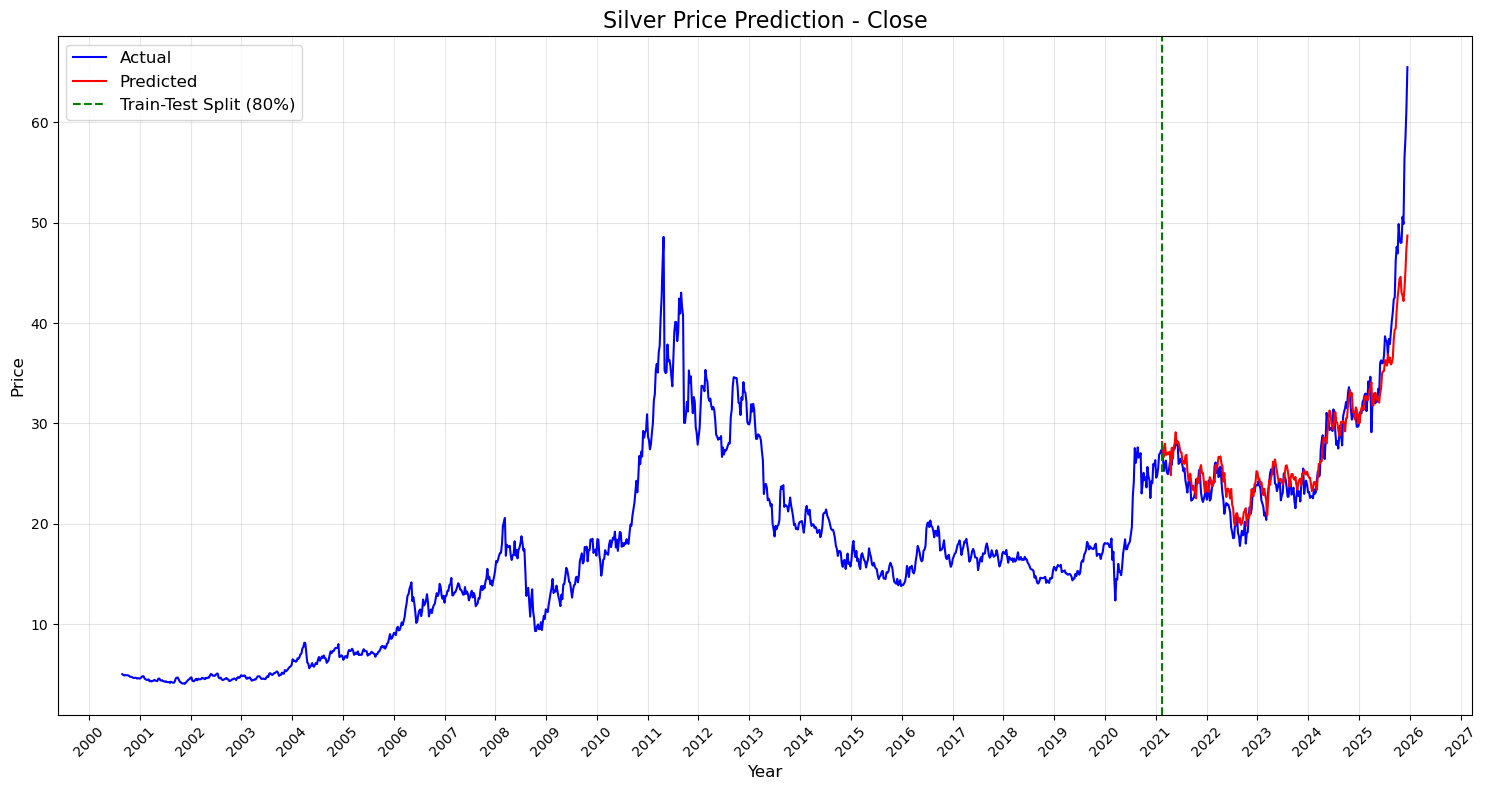

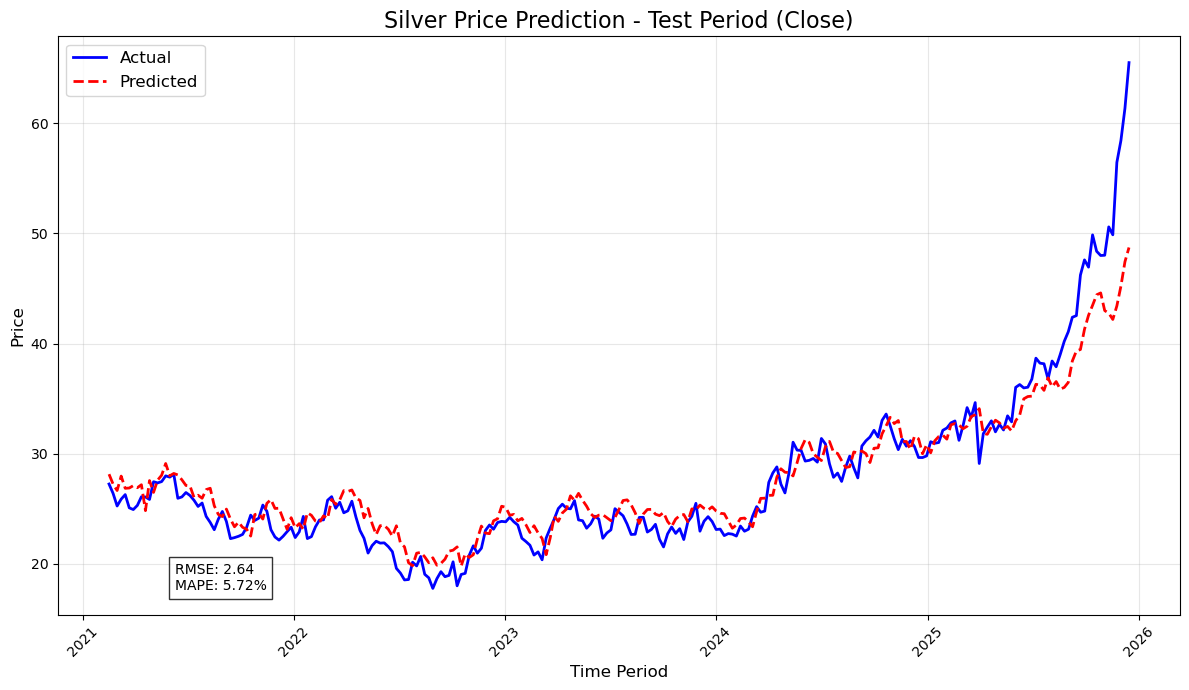


Model Performance Metrics:
Mean Squared Error: 6.9449
Root Mean Squared Error: 2.6353
Mean Absolute Error: 1.6726
R² Score: 0.8808
Mean Absolute Percentage Error: 5.72%


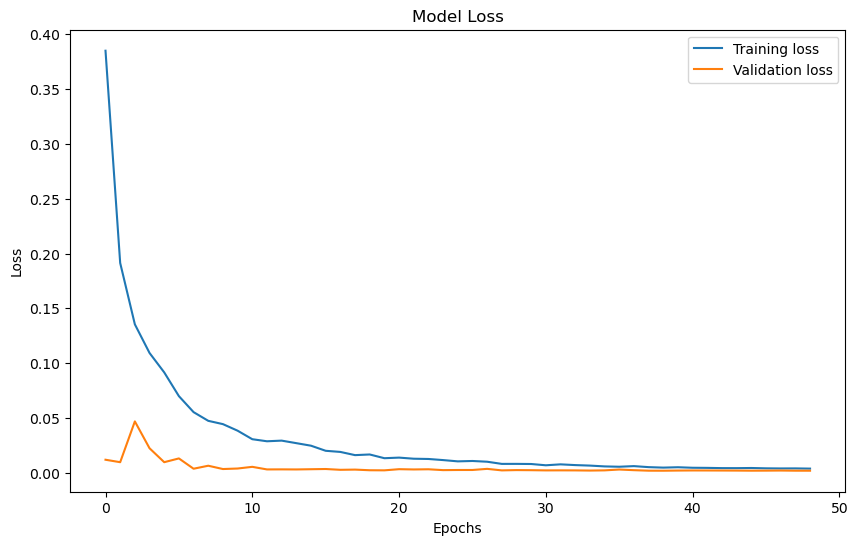

In [23]:
#RNN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import os
from tensorflow.keras.layers import SimpleRNN

# Set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# Load your data
def load_data(filepath):
    df = pd.read_csv(filepath)
    # Convert the first column to datetime if it's a date
    df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0])
    df.set_index(df.columns[0], inplace=True)
    print(df.shape)
    print(f"Data loaded successfully. Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    return df

# Function to prepare data for GRU model with 80-20 split
def prepare_data(df, target_col='Close', sequence_length=60):
    # Ensure all data is numeric
    numeric_df = df.select_dtypes(include=[np.number])
    print(f"Using {numeric_df.shape[1]} numeric features")
    
    # Create target scaler (for inverting predictions later)
    target_scaler = MinMaxScaler(feature_range=(0, 1))
    target_scaler.fit(df[[target_col]].values)
    
    # Scale all features
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(numeric_df)
    
    # Create sequences
    X, y = [], []
    for i in range(len(scaled_data) - sequence_length):
        X.append(scaled_data[i:i + sequence_length])
        # Get the target column index
        target_idx = list(numeric_df.columns).index(target_col)
        y.append(scaled_data[i + sequence_length, target_idx])
    
    X, y = np.array(X), np.array(y)
    print(f"Created {len(X)} sequences with shape {X.shape}")
    
    # Calculate the split point at 80%
    train_size = int(len(X) * 0.8)
    
    # Split data into train and test sets
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
    
    return X_train, X_test, y_train, y_test, scaler, target_scaler, numeric_df, train_size

# Function to build and train the RNN model
def build_rnn_model(X_train, y_train, X_test, y_test, epochs=100, batch_size=32):
    
    # Input dimensions
    n_timesteps, n_features = X_train.shape[1], X_train.shape[2]
    
    # Build model
    model = Sequential()
    
    model.add(SimpleRNN(units=50, return_sequences=True, 
                        input_shape=(n_timesteps, n_features)))
    model.add(Dropout(0.2))
    
    model.add(SimpleRNN(units=50, return_sequences=False))
    model.add(Dropout(0.2))
    
    model.add(Dense(units=1))
    
    # Compile
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    print(model.summary())
    
    # Early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    # Train
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=1
    )
    
    return model, history

# Function to make predictions
def make_predictions(model, X_test, target_scaler, y_test, numeric_df, target_col):
    # Make predictions
    print("Making predictions...")
    y_pred = model.predict(X_test)
    
    # Get original scale target values
    # First, create a container for the scaled values
    y_test_container = np.zeros((len(y_test), len(numeric_df.columns)))
    y_pred_container = np.zeros((len(y_pred), len(numeric_df.columns)))
    
    # Put the scaled values in the right column
    target_idx = list(numeric_df.columns).index(target_col)
    y_test_container[:, target_idx] = y_test
    y_pred_container[:, target_idx] = y_pred.flatten()
    
    # Transform back to original scale
    y_test_actual = target_scaler.inverse_transform(y_test_container)[:, target_idx]
    y_pred_actual = target_scaler.inverse_transform(y_pred_container)[:, target_idx]
    
    return y_test_actual, y_pred_actual

# Improved plotting function with years on x-axis
def plot_with_years(df, y_test_actual, y_pred_actual, target_col, sequence_length, train_size):
    """
    Creates a time series plot with years on x-axis, showing actual values for the entire dataset
    and predicted values for only the test portion (last 20%).
    """
    # Get the entire actual data
    actual_full = df[target_col].values
    
    # Create a dataframe with the full data
    result_df = pd.DataFrame(index=df.index)
    result_df['Actual'] = actual_full
    
    # Calculate the dates for the test data
    # We need to account for sequence_length and train_size
    test_start_idx = train_size + sequence_length
    test_dates = df.index[test_start_idx:]
    
    # Add predicted values only for the test portion
    result_df['Predicted'] = np.nan  # Initialize with NaN
    
    # Make sure we have enough test dates for our predictions
    if len(test_dates) >= len(y_pred_actual):
        result_df.loc[test_dates[:len(y_pred_actual)], 'Predicted'] = y_pred_actual
    else:
        print(f"Warning: Not enough test dates ({len(test_dates)}) for predictions ({len(y_pred_actual)})")
        # Use as many as we can
        result_df.loc[test_dates, 'Predicted'] = y_pred_actual[:len(test_dates)]
    
    # Create the plot
    plt.figure(figsize=(15, 8))
    
    # Plot full actual data
    plt.plot(result_df.index, result_df['Actual'], color='blue', label='Actual')
    
    # Plot predictions for test portion only
    plt.plot(result_df.index, result_df['Predicted'], color='red', label='Predicted')
    
    # Add vertical line at the train/test split
    split_date = df.index[test_start_idx]
    plt.axvline(x=split_date, color='green', linestyle='--', 
                label=f'Train-Test Split (80%)')
    
    # Format x-axis to show years
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    
    # Add labels and title
    plt.title(f'Silver Price Prediction - {target_col}', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Price', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the figure
    plt.savefig('silver_price_prediction_with_years.png', dpi=300)
    
    # Show the plot
    plt.show()
    
    return result_df

# Function to plot only test period predictions
def plot_test_predictions(df, y_test_actual, y_pred_actual, sequence_length, train_size, target_col='Close'):
    """
    Creates a plot showing only the test period with actual vs predicted values.
    
    Parameters:
    df (DataFrame): Original dataframe with datetime index
    y_test_actual (array): Actual values from test set
    y_pred_actual (array): Predicted values from model
    sequence_length (int): Number of timesteps used in each sequence
    train_size (int): Number of sequences in training set
    target_col (str): Name of target column being predicted
    
    Returns:
    DataFrame: DataFrame containing actual and predicted values
    """
    # Calculate the correct start index for test predictions
    test_start_idx = train_size + sequence_length
    
    # Get only the test period dates
    test_dates = df.index[test_start_idx:test_start_idx + len(y_pred_actual)]
    
    # Create a dataframe for the test period only
    test_df = pd.DataFrame(index=test_dates)
    test_df['Actual'] = y_test_actual[:len(test_dates)]
    test_df['Predicted'] = y_pred_actual[:len(test_dates)]
    
    # Create the plot
    plt.figure(figsize=(12, 7))
    
    # Plot data
    plt.plot(test_df.index, test_df['Actual'], 'b-', linewidth=2, label='Actual')
    plt.plot(test_df.index, test_df['Predicted'], 'r--', linewidth=2, label='Predicted')
    
    # Format x-axis based on the date range
    date_range = (test_df.index[-1] - test_df.index[0]).days
    
    if date_range > 365*2:  # More than 2 years
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    elif date_range > 90:  # More than 3 months
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    else:  # Less than 3 months
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
        plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    
    # Add labels and title
    plt.title(f'Silver Price Prediction - Test Period ({target_col})', fontsize=16)
    plt.xlabel('Time Period', fontsize=12)
    plt.ylabel('Price', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Calculate and display error metrics on the plot
    mse = np.mean((test_df['Actual'] - test_df['Predicted'])**2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((test_df['Actual'] - test_df['Predicted']) / test_df['Actual'])) * 100
    
    plt.figtext(0.15, 0.15, f'RMSE: {rmse:.2f}\nMAPE: {mape:.2f}%', 
                bbox=dict(facecolor='white', alpha=0.8), fontsize=10)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the figure
    plt.savefig('Silver_price_test_predictions.png', dpi=300)
    
    # Show the plot
    plt.show()
    
    return test_df

# Function to evaluate model
def evaluate_model(y_test_actual, y_pred_actual):
    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    r2 = r2_score(y_test_actual, y_pred_actual)
    
    print("\nModel Performance Metrics:")
    print(f'Mean Squared Error: {mse:.4f}')
    print(f'Root Mean Squared Error: {rmse:.4f}')
    print(f'Mean Absolute Error: {mae:.4f}')
    print(f'R² Score: {r2:.4f}')
    
    # Calculate percentage error
    mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100
    print(f'Mean Absolute Percentage Error: {mape:.2f}%')

# Main function
def main(filepath, target_col='Close', sequence_length=60, epochs=100, batch_size=32):
    print(f"Starting Silver price prediction with GRU model...")
    
    # Load data
    df = load_data(filepath)
    
    # Prepare data with 80-20 split
    X_train, X_test, y_train, y_test, scaler, target_scaler, numeric_df, train_size = prepare_data(
        df, target_col, sequence_length
    )
    
    # Build and train model
    model, history = build_rnn_model(X_train, y_train, X_test, y_test, epochs, batch_size)
    # Make predictions
    y_test_actual, y_pred_actual = make_predictions(model, X_test, target_scaler, y_test, numeric_df, target_col)
    
    # Plot both visualizations
    # 1. Full dataset with train/test split
    result_df = plot_with_years(df, y_test_actual, y_pred_actual, target_col, sequence_length, train_size)
    
    # 2. Test period only with metrics
    test_df = plot_test_predictions(df, y_test_actual, y_pred_actual, sequence_length, train_size, target_col)
    
    # Evaluate model
    evaluate_model(y_test_actual, y_pred_actual)
    
    # Plot training history
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training loss')
    plt.plot(history.history['val_loss'], label='Validation loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig('training_history.png')
    plt.show()
    
    return model, history, y_test_actual, y_pred_actual, result_df, test_df

# Example usage
if __name__ == "__main__":
    # Replace with your actual file path
    filepath = r"C:\Users\santh\silver_TTR_ratios.csv"
    target_col = "Close"  # Column to predict
    
    # Run the pipeline
    model, history, y_test_actual, y_pred_actual, result_df,test_df = main(
        filepath=filepath,
        target_col=target_col,
        sequence_length=60,  # Number of time steps to use as input
        epochs=60,
        batch_size=32
    )